Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 88s 119ms/step - loss: 28869.9707 - val_loss: 29374.0840
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 130ms/step - loss: 28866.8887 - val_loss: 29371.3848
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 87s 141ms/step - loss: 28864.2051 - val_loss: 29371.2637
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 145ms/step - loss: 28854.8867 - val_loss: 29371.2227
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 139ms/step - loss: 28827.1641 - val_loss: 29371.1895
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 142ms/step - loss: 28907.1738 - val_loss: 29371.1680
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 145ms/step - loss: 28900.8457 - val_loss: 29371.1582
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 157ms/step - loss: 28941.5996 - val_loss: 29371.1387
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 142ms/step - loss: 28869.8242 - val_loss: 29371.1328
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 146ms/step - loss: 28799.7617 - val_loss: 29371.1270
313/313 ━━━━━━━━━━━━━━━━━━━━ 

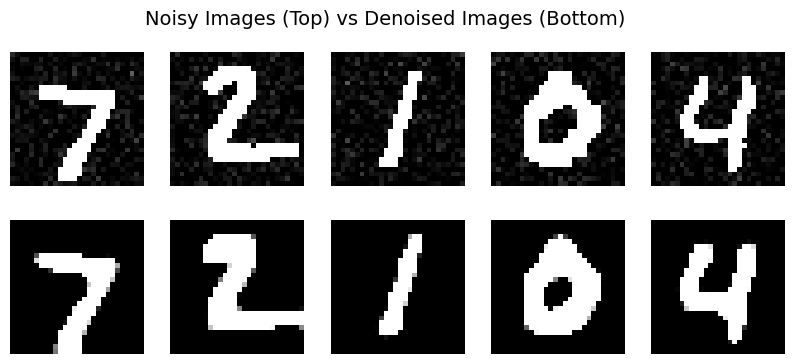

In [6]:

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset (only images)#
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize pixel values to range -1 to 1 for tanh activation#
x_train, x_test = (x_train - 0.5) * 2, (x_test - 0.5) * 209

# Reshape images to (28,28,1) for CNN layers#
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Add reduced Gaussian noise #
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values to be within -1 to 1#
x_train_noisy = np.clip(x_train_noisy, -1., 1.)
x_test_noisy = np.clip(x_test_noisy, -1., 1.)

# Define the Encoder#
encoder = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2), padding='same'),
    keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2), padding='same')
])

# Define the Decoder with tanh activation#
decoder = keras.Sequential([
    keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
    keras.layers.UpSampling2D((2, 2)),
    keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    keras.layers.UpSampling2D((2, 2)),
    keras.layers.Conv2D(1, (3, 3), activation='tanh', padding='same')  # tanh to allow -1 to 1 range#
])

# Define the Autoencoder Model (Encoder + Decoder)#
autoencoder = keras.Sequential([encoder, decoder])

# Compile the Autoencoder#
autoencoder.compile(optimizer='adam', loss='mse')

# Train the Autoencoder for more epochs#
autoencoder.fit(x_train_noisy, x_train, epochs=10, batch_size=128, validation_data=(x_test_noisy, x_test), verbose=1)

# Encode and Decode Test Images#
decoded_imgs = autoencoder.predict(x_test_noisy)

# Display Original Noisy Images vs. Denoised Images#
n = 5  # Number of images to display#
plt.figure(figsize=(10, 4))

for i in range(n):
    # Noisy Image #
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

    # Denoised Image #
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.suptitle("Noisy Images (Top) vs Denoised Images (Bottom)", fontsize=14)
plt.show()
